<a href="https://colab.research.google.com/github/GisellaDC/analisis-experiencia-clientes/blob/main/TP_final_NPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Abstracto**

El presente proyecto tiene como objetivo analizar y predecir el nivel de satisfacción del cliente a través del indicador NPS (Net Promoter Score), utilizando técnicas de Machine Learning.

El análisis se enmarca en un contexto de atención al cliente, donde resulta clave identificar patrones de comportamiento que influyen en la experiencia del usuario.

Este modelo está orientado a equipos de experiencia del cliente, analítica y operaciones, con el objetivo de mejorar la calidad del servicio, detectar factores de insatisfacción y optimizar procesos de atención.

A partir de datos históricos de interacciones, se construye un modelo de clasificación multiclase que permite predecir si un cliente es detractor, pasivo o promotor.

## **1. IMPORTS**

In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. CARGA DE DATOS**

In [2]:
df = pd.read_csv(
    '/content/drive/MyDrive/NPS-RES dic24.csv',
    encoding='latin1',
    sep=';'
)

## **3. EDA INICIAL**

In [3]:
df.head()
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 22 columns):
 #   Column                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                             --------------  -----  
 0   Fecha de inicio (+00:00 GMT)                                                                                       1601 non-null   object 
 1   Fecha de finalización (+00:00 GMT)                                                                                 1601 non-null   object 
 2   Duración (en segundos)                                                                                             1601 non-null   int64  
 3   Finalizado                                                                                                         1601 non-null   object 
 4   Fecha registrada (+00:00

,0
CSAT_ATENCION,1601
CSAT_CLARIDAD_MENU,20
"Antes de contactarte por este medio, Â¿Usaste algÃºn otro canal de atenciÃ³n para reclamar por este mismo motivo?",20
CSAT_CONOCIMIENTO,20
CSAT_CORDIALIDAD,20
CSAT_CLARIDAD,20
CSAT_DEMORA,20
NPS_CA,17
RESOLUCION,17
NPS_NUMERO,17


## **4. LIMPIEZA BASE**

In [4]:
df = df.drop(columns=[
    'CSAT_ATENCION',
    'Fecha de inicio (+00:00 GMT)',
    'Fecha de finalización (+00:00 GMT)',
    'Fecha registrada (+00:00 GMT)'
], errors='ignore')

df = df.dropna(subset=['NPS_GRUPO'])

df = df.drop(columns=[
    'NPS_NUMERO',
    'NPS_CA'
], errors='ignore')

## **5. FEATURE ENGINEERING**

In [5]:
# llamada larga
df['llamada_larga'] = (
    df['Duración (en segundos)'] >
    df['Duración (en segundos)'].mean()
).astype(int)

# uso otro canal
col_otro = [c for c in df.columns if 'Antes de contactarte' in c][0]

df['uso_otro_canal'] = df[col_otro].astype(str).str.lower().map({
    'si': 1,
    'no': 0
})

df = df.drop(columns=[col_otro], errors='ignore')

## **6. CSAT TRANSFORMACIÓN**

In [6]:
cols_csat = [
    'CSAT_CLARIDAD_MENU',
    'CSAT_DEMORA',
    'CSAT_CORDIALIDAD',
    'CSAT_CLARIDAD',
    'CSAT_CONOCIMIENTO'
]

def map_csat(valor):
    if pd.isna(valor):
        return np.nan

    v = str(valor).lower()

    if 'muy' in v:
        return 5
    elif 'bastante' in v:
        return 4
    elif 'ni satisfecho ni insatisfecho' in v:
        return 3
    elif 'poco' in v:
        return 2
    elif 'nada' in v:
        return 1
    else:
        return np.nan

for col in cols_csat:
    df[col] = df[col].apply(map_csat)

## **7. DEFINICIÓN DE X e Y**

In [7]:
from sklearn.preprocessing import LabelEncoder

X = df.drop('NPS_GRUPO', axis=1)

le = LabelEncoder()
y = le.fit_transform(df['NPS_GRUPO'])

print(set(y))

{np.int64(0), np.int64(1), np.int64(2)}


## **8. TRAIN / TEST SPLIT**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **9. PREPROCESSING**

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## **📊 10. MODELO 1 — LOGISTIC REGRESSION**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       106
           1       0.30      0.15      0.20        55
           2       0.73      0.90      0.80       156

    accuracy                           0.74       317
   macro avg       0.64      0.62      0.62       317
weighted avg       0.71      0.74      0.72       317



## **📊 11. MODELO 2 — RANDOM FOREST**

In [11]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85       106
           1       0.50      0.33      0.40        55
           2       0.77      0.89      0.82       156

    accuracy                           0.77       317
   macro avg       0.72      0.68      0.69       317
weighted avg       0.76      0.77      0.76       317



## **📊 12. MODELO 3 — XGBOOST**

In [12]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(eval_metric='mlogloss'))
])

pipe_xgb.fit(X_train, y_train)
pred_xgb = pipe_xgb.predict(X_test)

print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84       106
           1       0.35      0.35      0.35        55
           2       0.75      0.81      0.78       156

    accuracy                           0.73       317
   macro avg       0.67      0.65      0.66       317
weighted avg       0.73      0.73      0.73       317



## **13. CROSS VALIDATION**

*RF CV*

In [13]:
from sklearn.model_selection import cross_val_score

cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1_macro')
print("RF CV mean:", cv_rf.mean())

RF CV mean: 0.6656142134880804


*XGBoost CV*

In [14]:
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1_macro')
print("XGB CV mean:", cv_xgb.mean())

XGB CV mean: 0.6808468418506858


## **14. GRIDSEARCH**

In [15]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipe_rf,
    params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


*El modelo seleccionado fue Random Forest optimizado mediante GridSearchCV, ya que presentó el mejor balance entre estabilidad y rendimiento en validación cruzada, utilizando F1-macro como métrica principal.*

## **15. MODELO FINAL**

In [16]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

## **16. IMPORTANCIA DE VARIABLES**

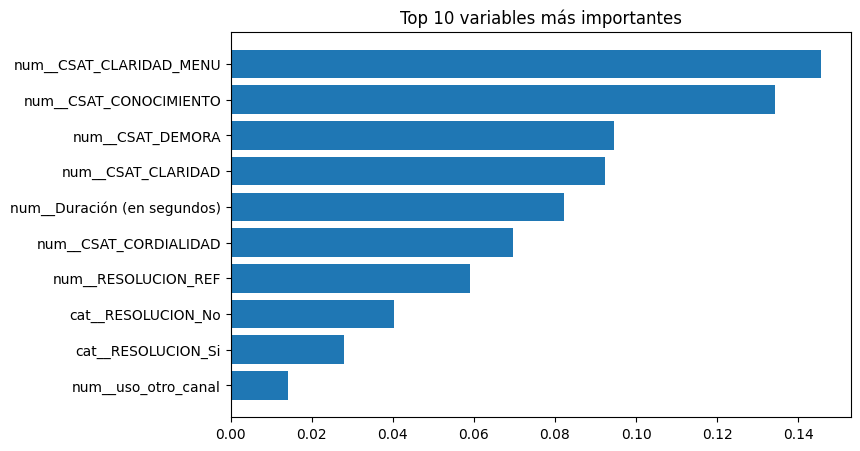

In [17]:
import matplotlib.pyplot as plt

best_model = grid.best_estimator_

feature_names = best_model.named_steps['prep'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

indices = importances.argsort()[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top 10 variables más importantes")
plt.show()

Las variables más influyentes en la predicción del NPS están asociadas principalmente a la calidad de la atención, tiempos de respuesta y tipo de interacción del usuario.

Esto permite identificar los factores clave que impactan directamente en la experiencia del cliente.

# **📌 17. EVALUACIÓN (MATRIZ DE CONFUSIÓN)**

              precision    recall  f1-score   support

           0       0.89      0.84      0.86       106
           1       0.47      0.25      0.33        55
           2       0.75      0.90      0.82       156

    accuracy                           0.77       317
   macro avg       0.70      0.66      0.67       317
weighted avg       0.75      0.77      0.75       317



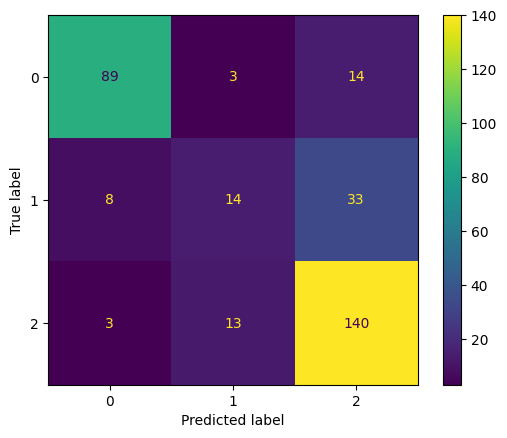

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()

## **🧠 18. Conclusión**

Se desarrolló un modelo de clasificación multiclase para predecir NPS (Detractor, Pasivo, Promotor).

Se compararon modelos de Regresión Logística, Random Forest y XGBoost, utilizando validación cruzada y optimización de hiperparámetros.

El modelo final seleccionado fue Random Forest optimizado, por su mejor balance entre desempeño y estabilidad.

Este modelo permite predecir el nivel de satisfacción del cliente a partir de variables operativas y de experiencia de usuario.

De esta forma, se pasa de una medición descriptiva a una gestión predictiva, identificando factores que influyen directamente en la percepción del cliente.

Esto permite a los equipos de atención priorizar mejoras en los puntos críticos detectados y optimizar la experiencia del usuario de forma proactiva.